In [1]:
import xarray as xr
import pandas as pd
import glob
import os
import math

import numpy as np
import re
from joblib import Parallel, delayed
from pathlib import Path
import matplotlib.pyplot as plt
import json


In [2]:
#%pip install -e ..

In [13]:
from proj2dhullsampler.pipeline import build_case, default_worker_count


from proj2dhullsampler.sampling_functions import orchestrate_test, sample_from_hulls_n


In [4]:
with open('apply_config.json', 'r') as file:
    config = json.load(file)

In [5]:
config

{'mode': 'python',
 'working_dir': '/glade/work/qingyuany/repo_data/',
 'case_name': 'test_iteration1_reconstruct',
 'result_name': 'iteration1',
 'data_paths': {'obs_nc': '/glade/u/home/qingyuany/repos/spatialtuning/data/nc_based_data/interpolated_obs.nc',
  'obs_tab': None,
  'para': '/glade/work/qingyuany/camml_proj/organized_manu_based/iteration1_para.csv',
  'ppe_nc': '/glade/work/qingyuany/camml_proj/organized_manu_based/iteration1_ppe.nc',
  'ppe_tab': None},
 'obs_dict': {'SWCF': 'swcrf_toa',
  'LWCF': 'lwcrf_toa',
  'TMQ': 'pwv',
  'FLUT': 'olr',
  'PRECT': 'pr',
  'FSNTOA': 'swabs_toa'},
 'lat_bins': {'start': -75, 'stop': 75, 'step': 5},
 'manual_regions': [{'nm': 'PRECT',
   'lat_min': 4,
   'lat_max': 7,
   'lon_min': 1,
   'lon_max': 359},
  {'nm': 'SWCF', 'lat_min': 4, 'lat_max': 7, 'lon_min': 1, 'lon_max': 359}],
 'n_sample': 100000,
 'prepare_case': {'n_cpus': 32, 'threshold_levels': [2.0]},
 'threshold_level': 2.0,
 'emultor_error_ratio_threshold': 0.2,
 'visualize_ch

In [6]:
working_dir = config["working_dir"]
case_name = config["case_name"]
result_name = config["result_name"]

Worker count: prepare_case.n_cpus=32 (job allocation reports 32 CPUs available; an explicit config value, if set, takes precedence)
Case directory does not exist yet; creating and preparing it.
Start creating new case
Check on nan variables passes: nan variables matching between obs and simulation
obs_shape: (174,), and ppe shape: (87, 174)
Manual and zonal indices match
obs and ppe variable names match


/glade/u/home/qingyuany/.local/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/u/home/qingyuany/.local/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/u/home/qingyuany/.local/lib/python3.10/site-packages/sklearn/gaussian_process/kernels.py:450: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__constant_value is close to the specified upper bound 0.8. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/glade/u/home/qingyuany/.

<class 'pandas.core.frame.DataFrame'>
                              0
SWCF_zonal_-75to-70    0.045977
SWCF_zonal_-70to-65    0.022989
SWCF_zonal_-65to-60    0.057471
SWCF_zonal_-60to-55    0.057471
SWCF_zonal_-55to-50    0.045977
...                         ...
FSNTOA_zonal_55to60    0.000000
FSNTOA_zonal_60to65    0.000000
FSNTOA_zonal_65to70    0.011494
local_PRECT_4_7_1_359  0.000000
local_SWCF_4_7_1_359   0.011494

[176 rows x 1 columns]


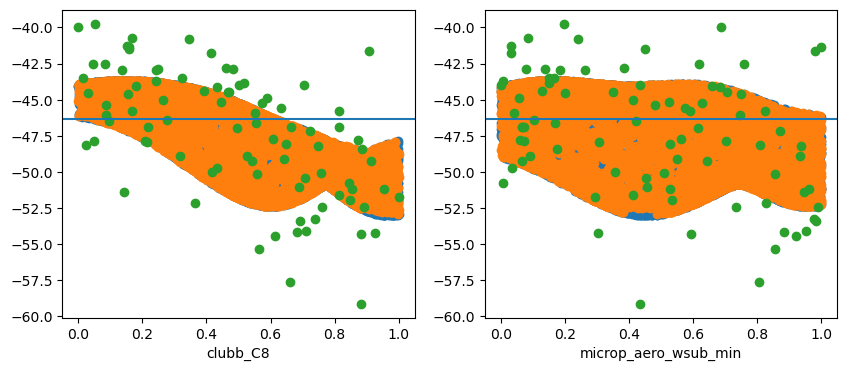

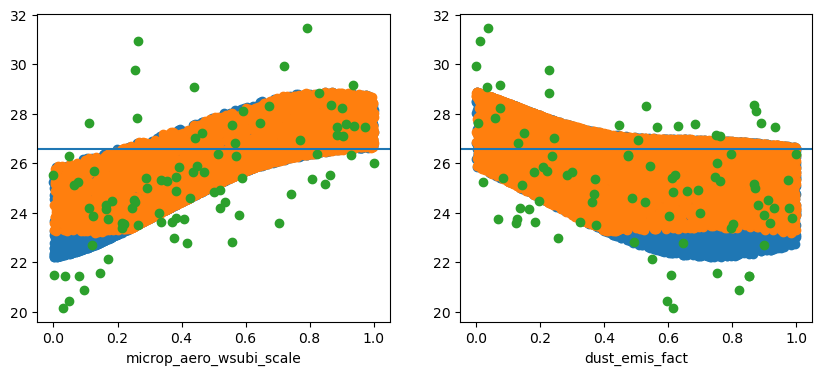

In [9]:
# Loads data per config["data_paths"], then either creates+prepares a new
# case or loads an existing one from working_dir/case_name - same logic
# run_apply.py uses for batch (PBS) runs, so both stay in sync automatically.
# mode="notebook" (rather than config["mode"]) so figures show inline here
# regardless of what mode the batch config was written for.
test_case = build_case(config, mode="notebook")

In [10]:
vars_to_drop = config["vars_to_drop"]
emultor_error_ratio_threshold = config["emultor_error_ratio_threshold"]
n_survive_threshold = config["n_survive_threshold"]
n_survive_threshold_2d = config["n_survive_threshold_2d"]
added_num = config["added_number_for_pairs"]
n_var_thre = config["n_var_thre"]
max_workers = config.get("max_workers", default_worker_count())
n_pts = config["n_pts"]
n_threshold = config["n_threshold"]
sample_threshold = config["sample_threshold"]
n_max = config["n_max"]
top_n = config["top_n"]

In [11]:
test_case.drop_by_name(vars_to_drop)
test_case.drop_by_emulator_performance(emultor_error_ratio_threshold)
test_case.drop_by_n_survive(n_survive_threshold)

Drop variables ['PRECT_zonal_-10to-5', 'PRECT_zonal_0to5', 'PRECT_zonal_20to25', 'PRECT_zonal_25to30', 'PRECT_zonal_50to55', 'PRECT_zonal_55to60', 'PRECT_zonal_60to65', 'SWCF_zonal_-75to-70', 'SWCF_zonal_-70to-65', 'LWCF_zonal_-75to-70', 'FSNTOA_zonal_-75to-70', 'FSNTOA_zonal_65to70', 'FLUT_zonal_60to65', 'FLUT_zonal_65to70', 'TMQ_zonal_-70to-65', 'TMQ_zonal_-65to-60', 'TMQ_zonal_55to60', 'TMQ_zonal_60to65', 'TMQ_zonal_65to70', 'PRECT_zonal_-75to-70', 'PRECT_zonal_-70to-65', 'PRECT_zonal_-65to-60', 'PRECT_zonal_-60to-55', 'PRECT_zonal_-55to-50', 'PRECT_zonal_-50to-45', 'PRECT_zonal_-25to-20', 'PRECT_zonal_-20to-15', 'PRECT_zonal_10to15', 'PRECT_zonal_30to35', 'PRECT_zonal_35to40', 'PRECT_zonal_40to45', 'PRECT_zonal_45to50', 'LWCF_zonal_-70to-65', 'LWCF_zonal_-45to-40', 'LWCF_zonal_-40to-35', 'LWCF_zonal_-35to-30', 'LWCF_zonal_30to35', 'FSNTOA_zonal_-70to-65', 'FSNTOA_zonal_-45to-40', 'FSNTOA_zonal_55to60', 'FSNTOA_zonal_60to65', 'FLUT_zonal_-45to-40', 'FLUT_zonal_-55to-50', 'FLUT_zonal

In [12]:
test_case.remove_var2d_auto(n_survive_threshold_2d, added_num=added_num)
test_case.drop_by_nvar_per_pair(n_var_thre)

There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
No need to consider non-overlapping
There are 0 groups that have no overlapping within own groups
No non-overlapping variables at this stage for the variables sharing the same 2 sensitive parameters
Finished dropping variables
Drop variables [] because when grouped together, they contribute to too little surviving ensemble members


In [18]:
test_case.prepare_for_sampling(n_pts=config['n_pts'], n_threshold=config['n_threshold'], sample_threshold=config['sample_threshold'], max_workers=max_workers)
#test_case.draw(n_pts=n_pts, n_threshold=n_threshold, sample_threshold=sample_threshold, max_workers=max_workers, n_max=n_max)

Finish constructing the 2d polygons/convex hulls
Running ('clubb_C8', 'microp_aero_wsub_min'), the 0th simulation
Current sampling size is 1
Previous sample size is 1
	 There is overlap for ('clubb_C8', 'microp_aero_wsub_min'). There are 35071 surviving ensemble members. 
	 	 The ***actual*** # of surviving pts is 35071
	 	 Proceed to the next iteration
===============================End of one iteration=======================================
Running ('clubb_C8', 'microp_aero_wsubi_scale'), the 1th simulation
Current sampling size is 1
Previous sample size is 35071
	 There is overlap for ('clubb_C8', 'microp_aero_wsubi_scale'). There are 9826 surviving ensemble members. 
	 	 The ***actual*** # of surviving pts is 9826
	 	 Proceed to the next iteration
===============================End of one iteration=======================================
Running ('clubb_c14', 'microp_aero_wsubi_scale'), the 2th simulation
Current sampling size is 1
Previous sample size is 9826
	 Find nothing or the 

ValueError: out_prev is None

In [19]:
test_case.prepare_for_sampling()
test_case.draw(n_pts=n_pts, n_threshold=n_threshold, sample_threshold=sample_threshold, max_workers=max_workers, n_max=n_max)

AttributeError: 'EmulatedDataStorage' object has no attribute 'valid_hulls'

In [26]:
test_case.save_samples_specifications(result_name, top_n = top_n)

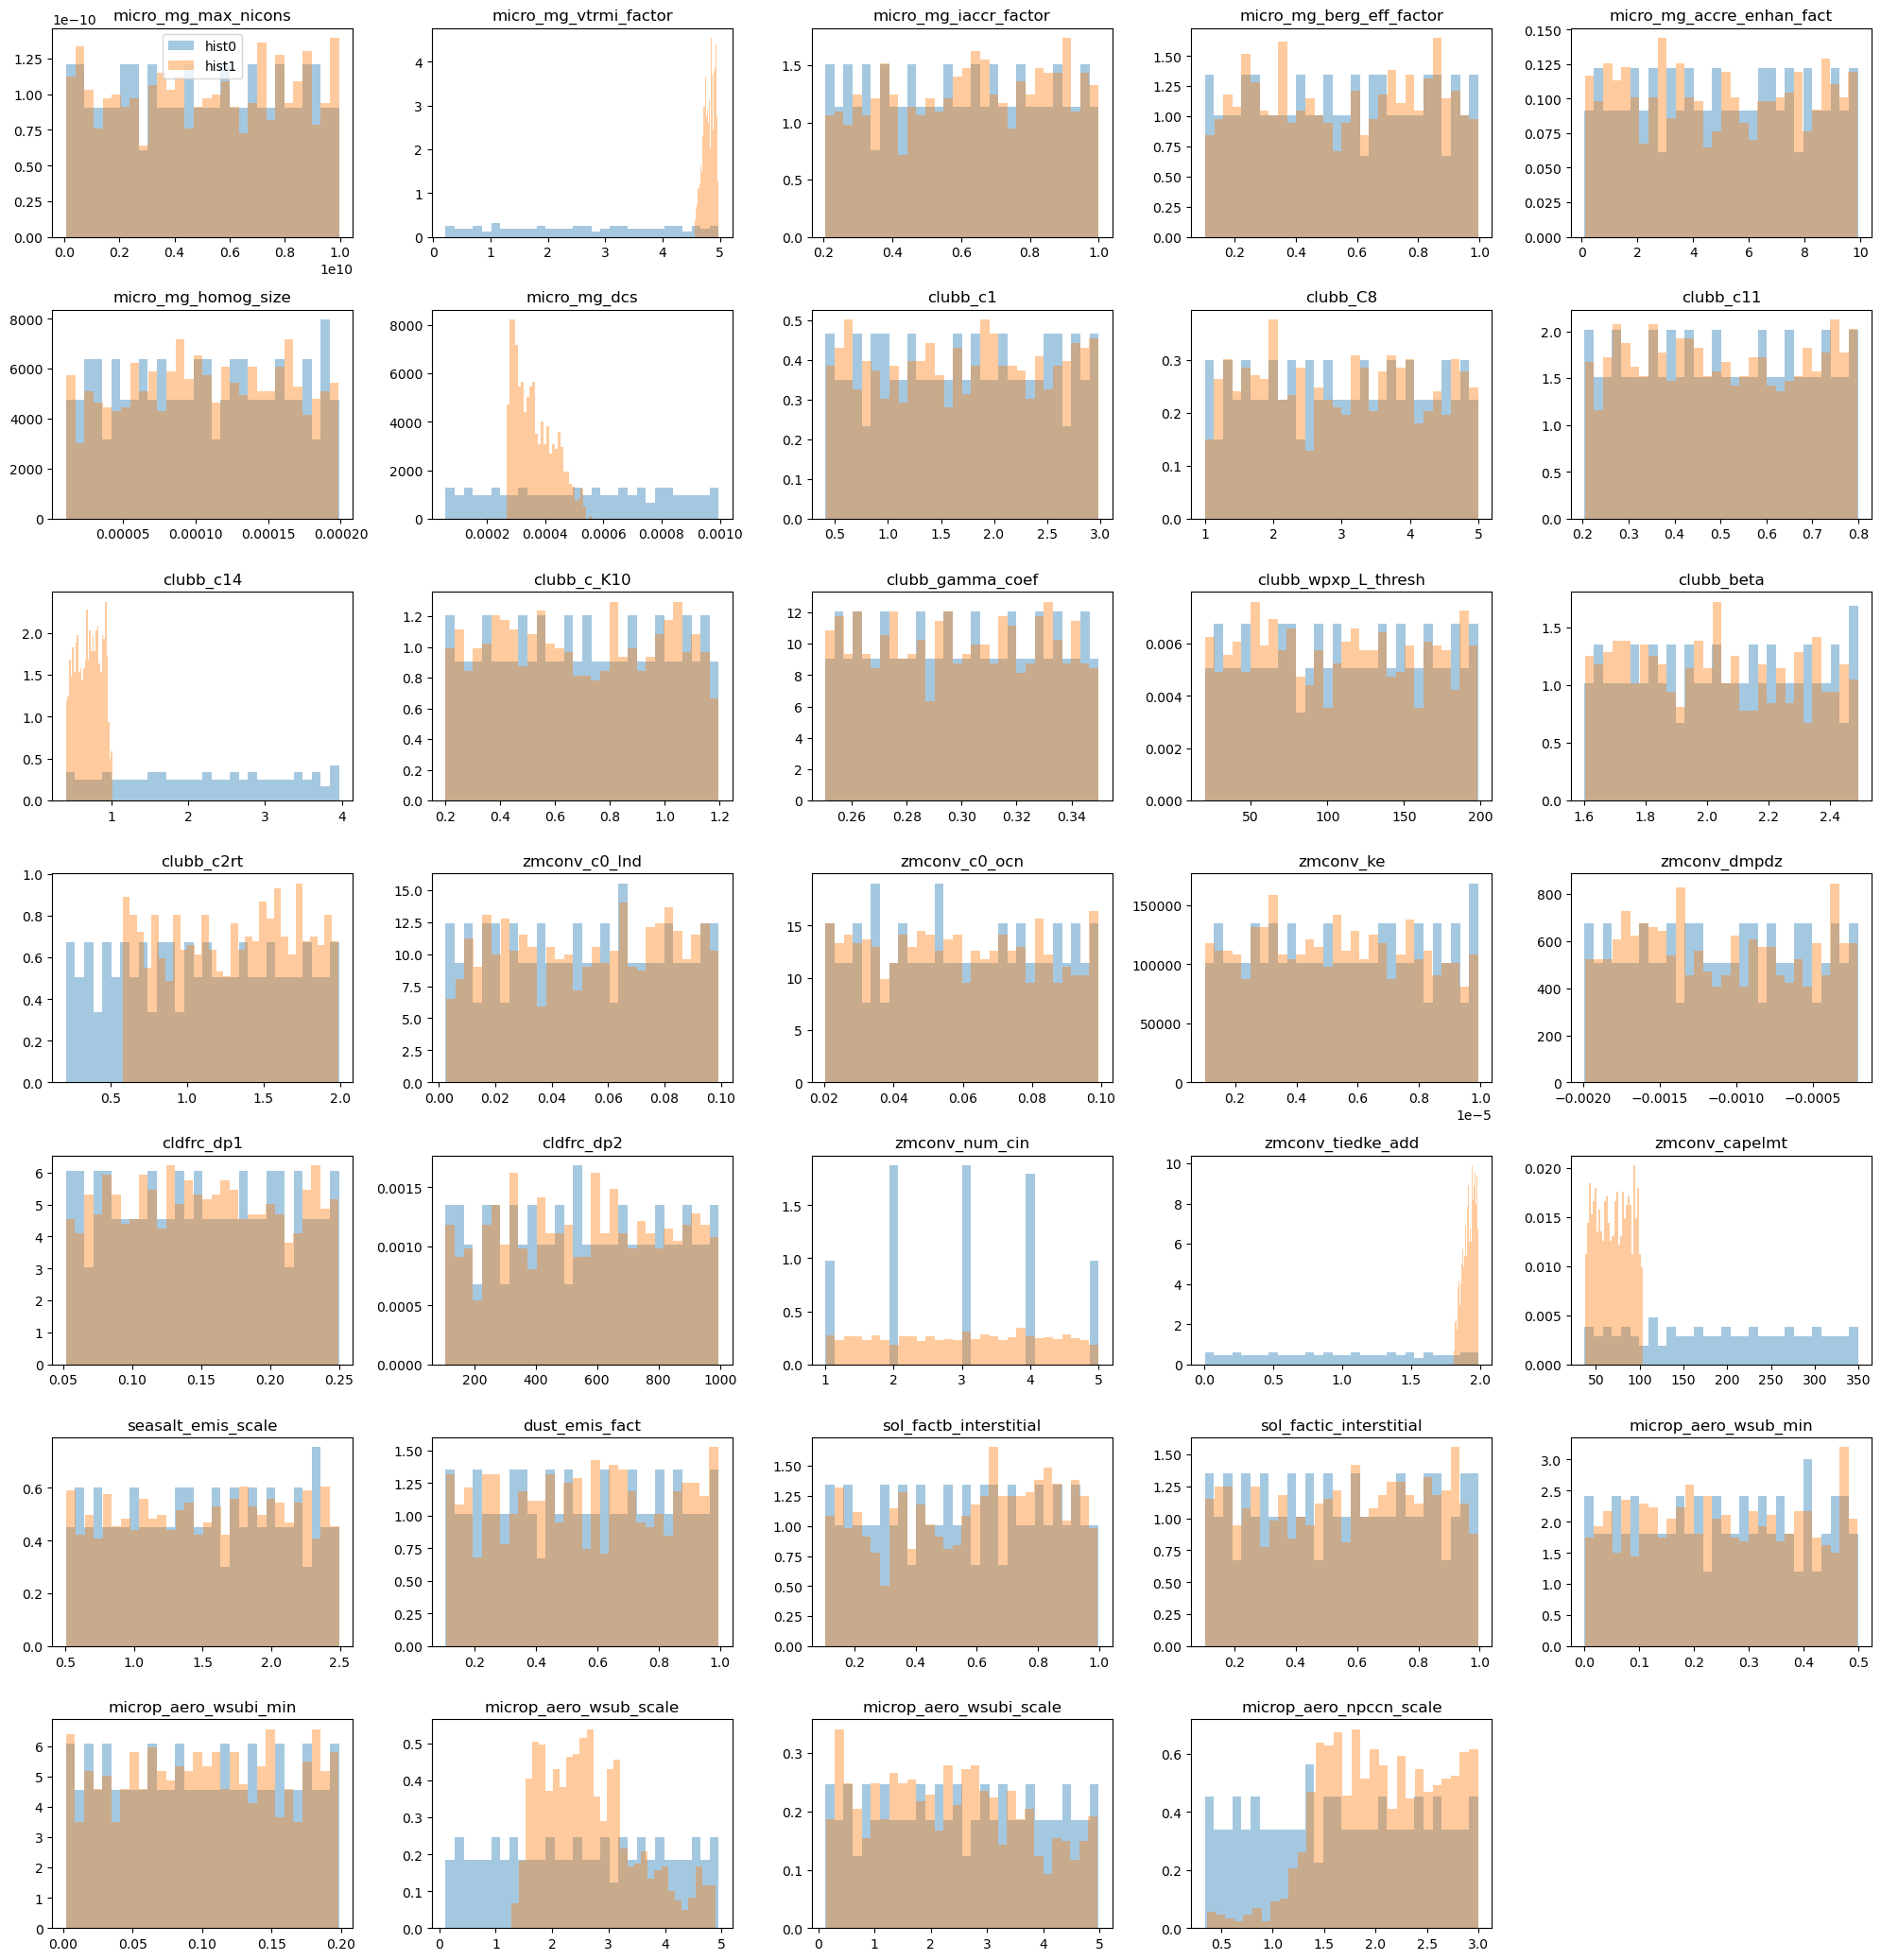

In [27]:
test_case.compare_with_original()

In [29]:
(test_case.results.unscaled_samples.max() - test_case.results.unscaled_samples.min()).prod()

4.628523259981454e-05

In [15]:
from proj2dhullsampler import HistoryMatching
hm = HistoryMatching(working_dir="/glade/work/qingyuany/repo_data/", case_name="test_iteration1_reconstruct")
hm.load_case()
hm.load_mask(threshold_level=2.0)

<class 'pandas.core.frame.DataFrame'>
                              0
SWCF_zonal_-70to-65    0.022989
SWCF_zonal_-65to-60    0.057471
SWCF_zonal_-60to-55    0.057471
SWCF_zonal_-55to-50    0.045977
SWCF_zonal_-50to-45    0.034483
...                         ...
FSNTOA_zonal_50to55    0.022989
FSNTOA_zonal_55to60    0.000000
FSNTOA_zonal_60to65    0.000000
local_PRECT_4_7_1_359  0.000000
local_SWCF_4_7_1_359   0.011494

[164 rows x 1 columns]


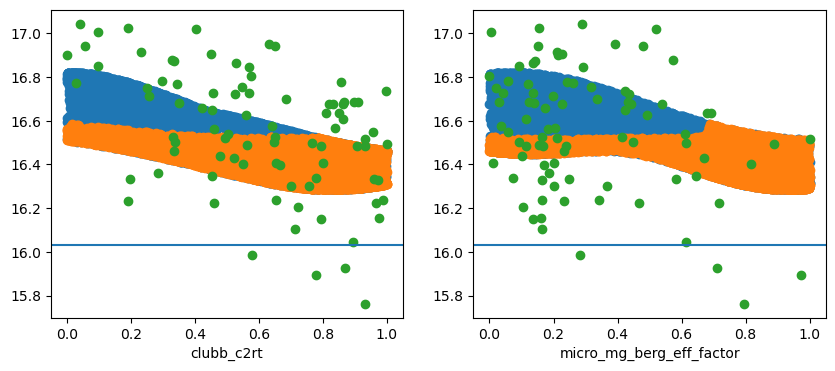

In [21]:
hm.visualize_check("TMQ_zonal_-45to-40")

In [162]:
surviving1 = (hm.p_emu[hm.tf_masks[var_group1].all(axis = 1)])
surviving2 = (hm.p_emu[hm.tf_masks[var_group2].all(axis = 1)])
surviving3 = (hm.p_emu[hm.tf_masks[var_group3b].all(axis = 1)])
surviving4 = (hm.p_emu[hm.tf_masks[var_group4].all(axis = 1)])


goup_all = (hm.p_emu[hm.tf_masks[var_group1 + var_group3].all(axis = 1)])


Text(0, 0.5, 'IceFallFac')

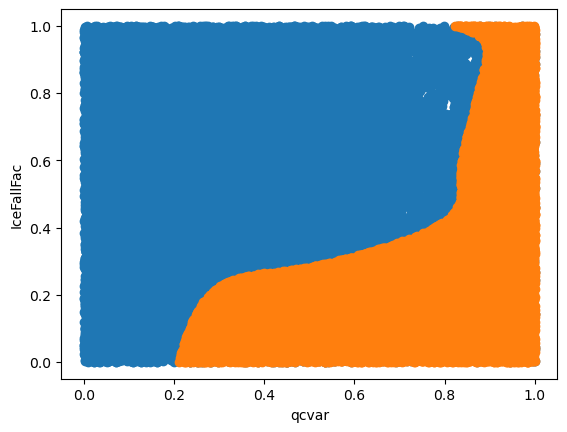

In [163]:

plt.scatter(surviving1.qcvar, surviving1.dcs)
#plt.scatter(surviving2.qcvar, surviving2.dcs)
plt.scatter(surviving3.qcvar, surviving3.dcs)
#plt.scatter(goup_all.qcvar, goup_all.dcs)


plt.xlabel('qcvar')
plt.ylabel('IceFallFac')


Text(0, 0.5, 'IceFallFac')

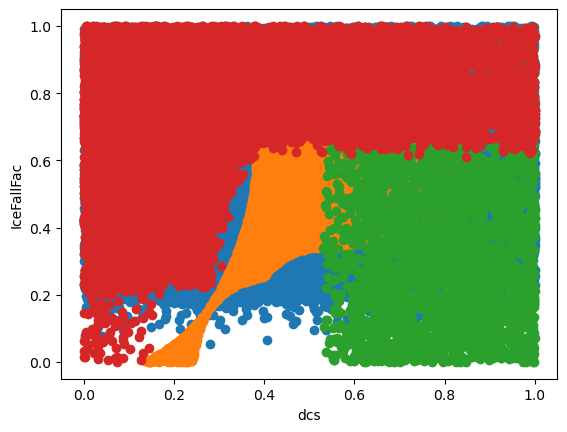

In [157]:

plt.scatter(surviving1.dcs, surviving1.IceFallFac)
plt.scatter(surviving2.dcs, surviving2.IceFallFac)
plt.scatter(surviving3.dcs, surviving3.IceFallFac)
plt.scatter(surviving4.dcs, surviving4.IceFallFac)

plt.xlabel('dcs')
plt.ylabel('IceFallFac')
